# Convert and Optimize YOLOX-s Object Detection with OpenVINO

This tutorial demonstrates how to run and optimize the YOLOX-s object detection model with OpenVINO. It is designed for enterprise developers building products with computer vision.

**You will learn:**
- Load YOLOX-s model and convert it to OpenVINO IR format
- Optimize inference with FP32/FP16 models
- Quantize the model using NNCF Post-Training Quantization (INT8)
- Build an inference pipeline for image input
- Create a Gradio demo supporting image upload and live webcam detection

**Table of contents:**
- [Setup and Prerequisites](#Setup)
- [Model Acquisition](#Model-Acquisition)
- [Inference Utilities](#Inference-Utilities)
- [Load OpenVINO Model](#Load-OpenVINO-Model)
- [Run Inference on Image](#Run-Inference)
- [NNCF Post-Training Quantization](#NNCF-Quantization)
- [Gradio Demo](#Gradio-Demo)

## Setup
<a id="Setup"></a>

Install OpenVINO 2026.0, NNCF, and other dependencies.

In [1]:
%pip install -q "openvino>=2026.0.0" "nncf>=2.19.0"
%pip install -q "torch>=2.8" "torchvision>=0.16" onnx tqdm opencv-python gradio matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\anish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys

# Notebook runs from its directory; add utils to path
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "utils").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))

# Fetch notebook_utils if needed
import requests
if not (NOTEBOOK_DIR / "notebook_utils.py").exists():
    r = requests.get("https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/2026.0/utils/notebook_utils.py")
    (NOTEBOOK_DIR / "notebook_utils.py").write_text(r.text)

from notebook_utils import download_file, device_widget

## Model Acquisition
<a id="Model-Acquisition"></a>

**Option A (recommended):** Download pre-converted OpenVINO IR model from YOLOX releases.

In [3]:
MODEL_DIR = Path("model/yolox_s")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Use ONNX model - OpenVINO reads ONNX directly (simpler, single file)
YOLOX_ONNX_URL = "https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.onnx"
MODEL_PATH = MODEL_DIR / "yolox_s.onnx"

if not MODEL_PATH.exists():
    print("Downloading YOLOX-s ONNX model...")
    download_file(YOLOX_ONNX_URL, filename="yolox_s.onnx", directory=MODEL_DIR)
else:
    print("Model found:", MODEL_PATH)

Model found: model\yolox_s\yolox_s.onnx


## Inference Utilities
<a id="Inference-Utilities"></a>

Import preprocessing, postprocessing, and visualization from `utils/yolox_utils.py`.

In [4]:
from utils.yolox_utils import (
    preproc,
    demo_postprocess,
    multiclass_nms,
    vis,
    COCO_CLASSES,
)

## Load OpenVINO Model
<a id="Load-OpenVINO-Model"></a>

Load the model with OpenVINO and compile for the target device.

In [5]:
import openvino as ov
from IPython.display import display

core = ov.Core()
ov_model = core.read_model(MODEL_PATH)

# Device selector: CPU (default), GPU, NPU, or AUTO - only shows available devices
device = device_widget(default="CPU", description="Device:")
display(device)
compiled_model = core.compile_model(ov_model, device.value)

# Model expects input [1, 3, 640, 640]
INPUT_SIZE = (640, 640)
input_name = compiled_model.input(0).get_any_name()
output_tensor = compiled_model.output(0)

Dropdown(description='Device:', options=('CPU', 'GPU', 'NPU', 'AUTO'), value='CPU')

## Run Inference on Image
<a id="Run-Inference"></a>

Download a test image and run detection.

In [6]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
IMAGE_PATH = DATA_DIR / "coco_bike.jpg"
if not IMAGE_PATH.exists():
    download_file(
        "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=DATA_DIR,
    )

In [7]:
import cv2
import numpy as np

def run_detection(image, model=compiled_model, conf_thr=0.25, nms_thr=0.45, rgb_input=False):
    """Run YOLOX detection. image: numpy array (BGR or RGB if rgb_input=True). Returns BGR annotated image."""
    if image is None or image.size == 0:
        return None
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    elif rgb_input:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    img_tensor, ratio = preproc(image, INPUT_SIZE)
    img_tensor = np.expand_dims(img_tensor, axis=0)
    result = model([img_tensor])[0]
    predictions = demo_postprocess(result, INPUT_SIZE)[0]
    boxes = predictions[:, :4]
    scores = predictions[:, 4:5] * predictions[:, 5:]
    boxes_xyxy = np.ones_like(boxes)
    boxes_xyxy[:, 0] = boxes[:, 0] - boxes[:, 2] / 2.0
    boxes_xyxy[:, 1] = boxes[:, 1] - boxes[:, 3] / 2.0
    boxes_xyxy[:, 2] = boxes[:, 0] + boxes[:, 2] / 2.0
    boxes_xyxy[:, 3] = boxes[:, 1] + boxes[:, 3] / 2.0
    boxes_xyxy /= ratio
    dets = multiclass_nms(boxes_xyxy, scores, nms_thr=nms_thr, score_thr=0.1)
    if dets is not None:
        final_boxes, final_scores, final_cls = dets[:, :4], dets[:, 4], dets[:, 5]
        image = vis(image.copy(), final_boxes, final_scores, final_cls, conf=conf_thr, class_names=COCO_CLASSES)
    return image

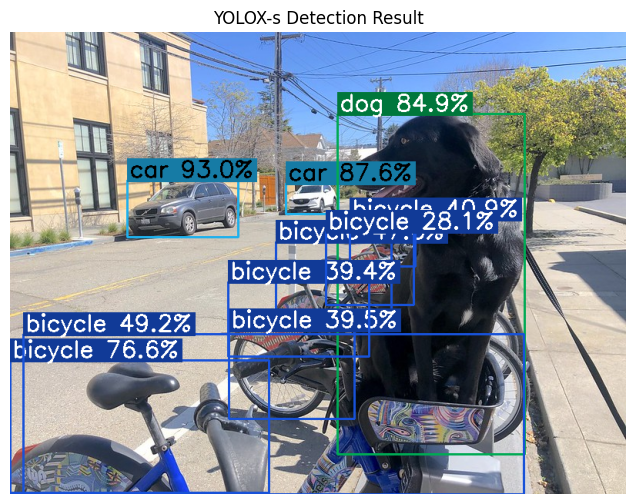

In [8]:
# Test on sample image
img = cv2.imread(str(IMAGE_PATH))
result_img = run_detection(img, conf_thr=0.25)
if result_img is not None:
    result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.imshow(result_rgb)
    plt.axis("off")
    plt.title("YOLOX-s Detection Result")
    plt.show()

## NNCF Post-Training Quantization
<a id="NNCF-Quantization"></a>

Apply INT8 quantization using NNCF for faster inference on CPU.

In [9]:
# Collect calibration images
# Prefer COCO128 from yolov8-optimization if available; else use data/ and test image
def get_calibration_images(n=300):
    images = []
    coco128_images = NOTEBOOK_DIR.parent / "yolov8-optimization" / "datasets" / "coco128" / "images" / "train2017"
    if coco128_images.exists():
        for p in sorted(coco128_images.glob("*.jpg"))[:n]:
            images.append(str(p))
    if len(images) < 50:
        # Use data folder and repeat test image to reach calibration count
        for p in DATA_DIR.glob("*.jpg"):
            images.append(str(p))
        while len(images) < 100 and IMAGE_PATH.exists():
            images.append(str(IMAGE_PATH))
    return images[:n]

calibration_images = get_calibration_images(200)
print(f"Calibration images: {len(calibration_images)}")

Calibration images: 128


In [10]:
import nncf

def transform_fn(data_item):
    """Transform image to model input format."""
    img = cv2.imread(data_item)
    if img is None:
        return np.zeros((1, 3, 640, 640), dtype=np.float32)  # fallback
    img_tensor, _ = preproc(img, INPUT_SIZE)
    return np.expand_dims(img_tensor, axis=0)

calibration_dataset = nncf.Dataset(calibration_images, transform_fn)
quantized_model = nncf.quantize(ov_model, calibration_dataset)

Output()

In [11]:
# Save quantized model and compile for selected device
QUANTIZED_PATH = MODEL_DIR / "yolox_s_int8.xml"
ov.save_model(quantized_model, QUANTIZED_PATH)
compiled_quantized = core.compile_model(quantized_model, device.value)
print("Quantized model saved:", QUANTIZED_PATH)
print("Using device:", device.value)

Quantized model saved: model\yolox_s\yolox_s_int8.xml
Using device: CPU


### INT8 inference on same image

Run detection with the quantized INT8 model on the same test image for visual comparison.

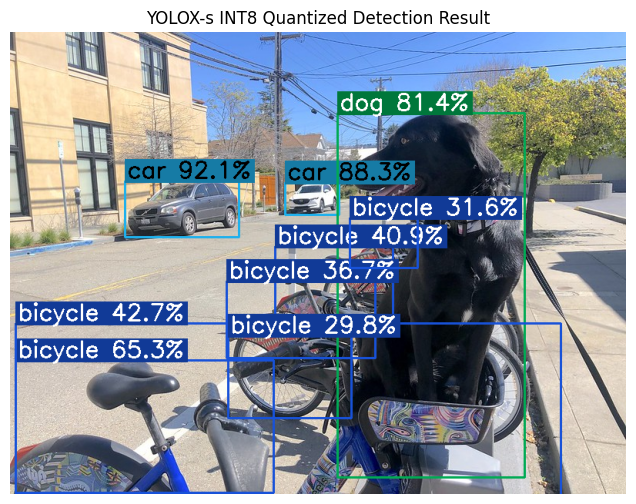

In [12]:
# INT8 inference on same image
img_int8 = cv2.imread(str(IMAGE_PATH))
result_int8 = run_detection(img_int8, model=compiled_quantized, conf_thr=0.25)
if result_int8 is not None:
    result_int8_rgb = cv2.cvtColor(result_int8, cv2.COLOR_BGR2RGB)
    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.imshow(result_int8_rgb)
    plt.axis("off")
    plt.title("YOLOX-s INT8 Quantized Detection Result")
    plt.show()

In [13]:
# Compare FP32 vs INT8 performance
import time

def benchmark(model, n_warmup=10, n_iter=50):
    dummy = np.random.randn(1, 3, 640, 640).astype(np.float32)
    for _ in range(n_warmup):
        model([dummy])
    start = time.perf_counter()
    for _ in range(n_iter):
        model([dummy])
    return (time.perf_counter() - start) / n_iter * 1000

fp32_ms = benchmark(compiled_model)
int8_ms = benchmark(compiled_quantized)
print(f"FP32: {fp32_ms:.2f} ms | INT8: {int8_ms:.2f} ms | Speedup: {fp32_ms/int8_ms:.2f}x")

FP32: 187.34 ms | INT8: 62.47 ms | Speedup: 3.00x


## Gradio Demo
<a id="Gradio-Demo"></a>

Interactive demo: upload an image or enable webcam for live detection.

In [14]:
import gradio as gr
from pathlib import Path

# Use quantized model if available (faster), else FP32
base_ir_model = quantized_model if 'quantized_model' in dir() else ov_model

# Build device list: CPU first (default), then GPU, NPU - only available devices
_avail = core.available_devices
_device_choices = ["CPU"] + [d for d in _avail if d != "CPU"]

# Cache compiled models per device
_compiled_cache = {}

def get_demo_model(device_name):
    if device_name not in _compiled_cache:
        try:
            _compiled_cache[device_name] = core.compile_model(base_ir_model, device_name)
        except Exception:
            _compiled_cache[device_name] = core.compile_model(base_ir_model, "CPU")
    return _compiled_cache[device_name]

def _ensure_numpy(img):
    """Handle Gradio output: numpy, dict, str path, file-like (has .name), or None."""
    if img is None:
        return None
    path = None
    if isinstance(img, np.ndarray):
        return img
    if isinstance(img, str) and len(img) > 0:
        path = img
    elif isinstance(img, (list, tuple)) and len(img) > 0:
        it = img[0]
        path = it if isinstance(it, str) else getattr(it, "name", getattr(it, "path", None))
    elif hasattr(img, "name"):
        path = getattr(img, "name", None)
    elif hasattr(img, "path"):
        path = getattr(img, "path", None)
    elif hasattr(img, "__fspath__"):
        path = str(img)
    elif isinstance(img, dict):
        path = img.get("path") or img.get("name")
        if path is None and "image" in img:
            im = img["image"]
            return np.array(im) if im is not None else None
    if path and not callable(path):
        path = str(Path(path))  # Cross-platform path normalization
        arr = cv2.imread(path)
        if arr is not None:
            return cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
    return None

def detect_and_show(image, conf_thr, device_name):
    img = _ensure_numpy(image)
    if img is None:
        return None
    try:
        model = get_demo_model(device_name)
        result = run_detection(img, model=model, conf_thr=conf_thr, rgb_input=True)
        return cv2.cvtColor(result, cv2.COLOR_BGR2RGB) if result is not None else None
    except Exception as e:
        print(f"Detection error: {e}")
        return None

with gr.Blocks(title="YOLOX-s Object Detection") as demo:
    gr.Markdown("# YOLOX-s Object Detection with OpenVINO")
    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.Image(sources=["upload", "webcam"], label="Image (upload, drop, or webcam)", height=380)
            _sample_paths = [[str(IMAGE_PATH)]] if IMAGE_PATH.exists() else []
            if _sample_paths:
                gr.Examples(_sample_paths, inputs=inp, label="Sample (click to load)", run_on_click=False)
        with gr.Column(scale=1):
            out = gr.Image(label="Detection result", height=380)
    with gr.Row():
        run_btn = gr.Button("Run Detection", variant="primary")
        conf_slider = gr.Slider(0.1, 0.9, 0.25, label="Confidence threshold")
        device_dropdown = gr.Dropdown(choices=_device_choices, value="CPU", label="Device")
    gr.Markdown("Upload, drop, or capture from webcam. Click a sample to load it. Click **Run Detection** to run inference.")

    run_btn.click(detect_and_show, [inp, conf_slider, device_dropdown], out)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
